# Delivery Delays & Customer Behavior: Olist E-Commerce Analysis

**Business question:** Do delivery delays hurt customer satisfaction and repeat purchases?

Analysis of ~100K orders from the Olist Brazilian e-commerce dataset — covering delay rates, their link to review scores and repeat purchases, and where delays concentrate geographically.

**Tools:** PostgreSQL (SQL) → pandas/seaborn (Colab)

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
base_url = "https://raw.githubusercontent.com/Amit2312/Olist-delivery-delay-analysis/refs/heads/main/data/"

customers = pd.read_csv(base_url + "customers.csv")
order_items = pd.read_csv(base_url + "order_items.csv")
order_reviews = pd.read_csv(base_url + "order_reviews.csv")
orders = pd.read_csv(base_url + "orders.csv")
payments = pd.read_csv(base_url + "payments.csv")
products = pd.read_csv(base_url + "products.csv")
sellers = pd.read_csv(base_url + "sellers.csv")

In [12]:
sql_base_url = "https://raw.githubusercontent.com/Amit2312/Olist-delivery-delay-analysis/refs/heads/main/sql_result/"

## **Q1: What share of orders arrive later than their estimated delivery date?**

```sql
-- Scope: delivered orders only, with both estimated and actual delivery dates present

-- Late = order_delivered_customer_date > order_estimated_delivery_date

-- Output: single percentage (share_of_late_orders)

WITH valid_orders AS (
    SELECT
        order_id,
        NULLIF(TRIM(order_purchase_timestamp), '')::timestamp AS purchase_ts,
        NULLIF(TRIM(order_delivered_customer_date), '')::date AS delivered_date,
        NULLIF(TRIM(order_estimated_delivery_date), '')::date AS estimated_date
    FROM target.orders
    WHERE order_status = 'delivered'
        AND NULLIF(TRIM(order_estimated_delivery_date), '') IS NOT NULL
        AND NULLIF(TRIM(order_delivered_customer_date), '') IS NOT NULL
)
SELECT
    ROUND(SUM(CASE WHEN delivered_date > estimated_date THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2)
     AS share_of_late_orders
FROM valid_orders

In [13]:
total_late_delivery_share = pd.read_csv(sql_base_url + "q1_overall_late_share.csv")
total_late_delivery_share

,share_of_late_orders
0,6.77


**Overall share of late deliveries: 6.77%**

**Trend: Is the late-delivery rate stable, or event-driven?**

The overall late-delivery rate is 6.77%, but a single number can't show whether that's a stable baseline or the result of a few bad months pulling the average up. Below, the SQL export of late-delivery share by month is loaded, months with only a single order are excluded (not enough volume to be meaningful), and the result is plotted against the overall average.

```sql
-- Scope: delivered orders only, with both estimated and actual delivery dates present

-- Late = order_delivered_customer_date > order_estimated_delivery_date

-- Output: month-on-month percentage (share_of_late_orders)

WITH valid_orders AS (
    SELECT
        order_id,
        NULLIF(TRIM(order_purchase_timestamp), '')::timestamp AS purchase_ts,
        NULLIF(TRIM(order_delivered_customer_date), '')::date AS delivered_date,
        NULLIF(TRIM(order_estimated_delivery_date), '')::date AS estimated_date
    FROM target.orders
    WHERE order_status = 'delivered'
        AND NULLIF(TRIM(order_estimated_delivery_date), '') IS NOT NULL
        AND NULLIF(TRIM(order_delivered_customer_date), '') IS NOT NULL
)
SELECT
    DATE_TRUNC('month', purchase_ts)::date AS order_month,
    COUNT(*) AS order_count,
    ROUND(SUM(CASE WHEN delivered_date > estimated_date THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2)
     AS share_of_late_orders
FROM valid_orders
GROUP BY 1
ORDER BY 1

In [14]:
monthly_late_df = pd.read_csv(sql_base_url + "q1_monthly_late_trend.csv")

In [15]:
monthly_late_df_new = monthly_late_df[monthly_late_df['order_count']>1]
monthly_late_df_new.head()

,order_month,order_count,share_of_late_orders
1,2016-10-01,265,0.75
3,2017-01-01,750,2.93
4,2017-02-01,1653,2.96
5,2017-03-01,2546,4.56
6,2017-04-01,2303,6.56


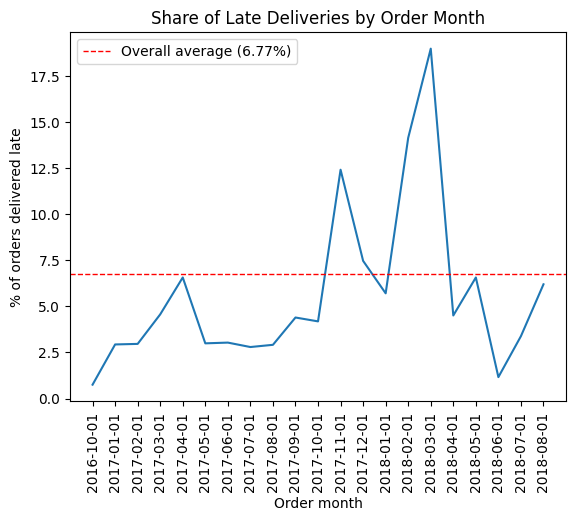

In [16]:
sns.lineplot(data=monthly_late_df_new, x='order_month', y='share_of_late_orders')
plt.axhline(y=6.77, color='red', linestyle='--', linewidth=1, label='Overall average (6.77%)')
plt.legend()
plt.title('Share of Late Deliveries by Order Month')
plt.ylabel('% of orders delivered late')
plt.xlabel('Order month')
plt.xticks(rotation=90)
plt.show()

Late delivery rate over time. The dashed line marks the overall average (6.77%) computed in the previous query. Rather than sitting near that average consistently, the monthly rate is dominated by two sharp spikes: November 2017, which coincides with Black Friday order volume, and February–March 2018, which coincides with a period some external analyses of this dataset attribute to logistics strikes in Brazil (worth independent verification before treating as confirmed). Outside these events, the typical month runs closer to 3–5% — meaning the 6.77% headline figure is meaningfully shaped by a small number of disruption months rather than reflecting a stable baseline.

## **Q2: Does a late delivery correlate with a lower review score?**

**Data quality check:**

```sql
-- Check whether any order_id has multiple review rows before averaging scores

SELECT order_id, count(*) as review_count, array_agg(review_score) as scores
FROM target.order_reviews
GROUP BY 1
HAVING count(*) > 1

In [17]:
duplicate_rows = pd.read_csv(sql_base_url + "q2_duplicate_reviews.csv")
duplicate_rows.head(10)

,order_id,review_count,scores
0,1c308eca3f339414a92e518e2a2e5ee9,2,"{2,1}"
1,169d7e0fd71d624d306f132acd791cbe,2,"{5,5}"
2,cf73e2cb1f4a9480ed70c154da3d954a,2,"{5,5}"
3,cbf088f9ac169d9c7eddcaa9c5e465fe,2,"{5,5}"
4,2ee31a66f128a2600acad318260c9e01,2,"{5,5}"
5,23afc00db0b1c005196306f02e1c1178,2,"{5,5}"
6,2daee070f2042c8b7a8e9fdde778a31a,2,"{5,5}"
7,2c6df2cdea838bd21bc2dc78dac3029b,2,"{5,5}"
8,ec7c6bfed4adf361322a0b6d6e5bfc51,2,"{5,5}"
9,4863e15fa53273cc7219c58f5ffda4fb,2,"{1,1}"


~547 orders have more than one review row, and scores often differ between them (not just
duplicate inserts) — so a plain average would blend two different opinions into one meaningless
number. Kept the most recent review per order instead.

```sql
-- Scope: delivered orders only, with both estimated and actual delivery dates present,
--- joined to each order's most recent review.

-- Output: avg review_score and order count, grouped by delay / on_time

WITH valid_orders AS (
    SELECT
        order_id,
        NULLIF(TRIM(order_purchase_timestamp), '')::timestamp AS purchase_ts,
        NULLIF(TRIM(order_delivered_customer_date), '')::date AS delivered_date,
        NULLIF(TRIM(order_estimated_delivery_date), '')::date AS estimated_date
    FROM target.orders
    WHERE order_status = 'delivered'
        AND NULLIF(TRIM(order_estimated_delivery_date), '') IS NOT NULL
        AND NULLIF(TRIM(order_delivered_customer_date), '') IS NOT NULL
),
valid_reviews AS (
    SELECT
        order_id,
        review_score,
        ROW_NUMBER() OVER (
            PARTITION BY order_id
            ORDER BY
                TO_TIMESTAMP(review_creation_date, 'DD/MM/YY HH24:MI')::date DESC,
                TO_TIMESTAMP(review_answer_timestamp, 'DD/MM/YY HH24:MI') DESC,
                review_id DESC
        ) AS rnk
    FROM target.order_reviews
)
SELECT
    CASE WHEN vo.delivered_date > vo.estimated_date THEN 'delay' ELSE 'on_time' END AS delivery,
    ROUND(AVG(vr.review_score), 2) AS avg_review_score,
    COUNT(*) AS num_of_orders
FROM valid_orders vo
JOIN valid_reviews vr ON vo.order_id = vr.order_id
WHERE vr.rnk = 1
GROUP BY 1

In [18]:
avg_review_score_df = pd.read_csv(sql_base_url + "q2_review_score_by_delay.csv")
avg_review_score_df

,delivery,avg_review_score,num_of_orders
0,delay,2.27,6381
1,on_time,4.29,89443


**Sanity check against Q1:**

Q1's overall late-delivery share was 6.77% across all valid orders. In Q2, restricting to orders
that also have a review, delayed orders are 6,381 / 95,824 = 6.66% of the total — close to Q1's
figure, with the small gap explained by orders that have no review at all being dropped by the
inner join.

**Interpretation:**

**Avg review score, delayed vs on-time deliveries**

- On-time: 4.29 avg (n=89,443)
- Delayed: 2.27 avg (n=6,381)

Delayed orders score 2 points lower on average — a large, consistent gap given both groups are
well-sampled. Late delivery looks like one of the strongest drivers of poor review scores in this
dataset.

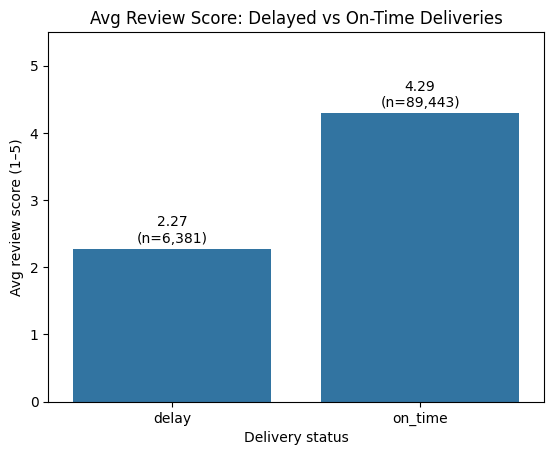

In [19]:
fig, ax = plt.subplots()
bars = sns.barplot(data=avg_review_score_df, x='delivery', y='avg_review_score', ax=ax)

for i, row in avg_review_score_df.iterrows():
    ax.text(i, row['avg_review_score'] + 0.1,
             f"{row['avg_review_score']}\n(n={row['num_of_orders']:,})",
             ha='center', fontsize=10)

plt.title('Avg Review Score: Delayed vs On-Time Deliveries')
plt.ylabel('Avg review score (1–5)')
plt.xlabel('Delivery status')
plt.ylim(0, 5.5)
plt.show()

## **Q3: Do customers who experienced a delay buy again less often than customers who didn't?**

**Step 1: Empirical check — how long until customers reorder?**

Before setting a fair comparison window for delayed vs. on-time reorder rates, we look at how long it actually takes customers who did reorder to place their second order. This distribution informs the cutoff window (W) used later to avoid comparing customers who've had unequal time to reorder.

Distribution of days between first and second order, among customers who did
reorder. Order pairs under 60 seconds apart are excluded — a data artifact
(likely Superstore splitting one checkout into multiple order rows), confirmed by
a sharp drop-off in pair counts past 30 seconds.

```sql
--- Customer = customer_unique_id
--- reference order = each customer's first valid (delivered) order
--- bought again = any later order, regardless of its status

WITH
	ranked_orders AS (
		SELECT
			c.customer_unique_id,
			o.order_id,
			NULLIF(TRIM(o.order_purchase_timestamp), '')::timestamp AS purchase_ts,
			ROW_NUMBER() OVER (
				PARTITION BY
					c.customer_unique_id
				ORDER BY
					NULLIF(TRIM(o.order_purchase_timestamp), '')::timestamp,
					o.order_id
			) AS rnk
		FROM
			target.orders o
			JOIN target.customers c ON o.customer_id = c.customer_id
		WHERE
			NULLIF(TRIM(o.order_purchase_timestamp), '') IS NOT NULL
	)
SELECT
	r1.customer_unique_id,
	r1.order_id AS first_order_id,
	r2.order_id AS second_order_id,
	round(
		extract(
			epoch
			FROM
				(r2.purchase_ts - r1.purchase_ts) / 86400
		),
		2
	) AS days_between_orders
FROM
	ranked_orders r1
	JOIN ranked_orders r2 ON r1.customer_unique_id = r2.customer_unique_id
WHERE
	r1.rnk = 1
	AND r2.rnk = 2
	AND extract(
		epoch
		FROM
			(r2.purchase_ts - r1.purchase_ts)
	) > 60
ORDER BY
	4 DESC

In [20]:
dbo_df = pd.read_csv(sql_base_url + "q3_days_between_orders.csv")
dbo_df.head()

,customer_unique_id,first_order_id,second_order_id,days_between_orders
0,ccafc1c3f270410521c3c6f3b249870f,3d58fd1ee438a43f2a826dda6b013519,dcb36b511fcac050b97cd5c05de84dc3,608.978912
1,d8f3c4f441a9b59a29f977df16724f38,2511cdf205337513507a1863f0098d39,b2947cf9a8d3084369dfcbe9663dd545,582.864363
2,94e5ea5a8c1bf546db2739673060c43f,64f5569ef96004a1e1137bdf28fd4c45,2f53e1db0b2a17564ef12fe69d65a9df,580.693322
3,87b3f231705783eb2217e25851c0a45d,c98b0fbac2717f072d5089e8af088304,6d86a700fbdfec909998eefa9110f3e9,572.686840
4,4e23e1826902ec9f208e8cc61329b494,31b0dd6152d2e471443debf037ae171d,876fd8c751a56ed982b5a72dca56937f,524.413495


In [21]:
dbo_df.shape

(2254, 4)

In [22]:
dbo_df['days_between_orders'].describe()

,days_between_orders
count,2254.000000
mean,106.836239
std,115.393925
min,0.001204
25%,16.077344
50%,62.068600
75%,167.127164
max,608.978912


In [23]:
dbo_df['days_between_orders'].quantile([0.5, 0.75,.8,.85, 0.9, 0.95])

,days_between_orders
0.50,62.068600
0.75,167.127164
0.80,195.824956
0.85,232.844579
0.90,281.324582
0.95,343.163907


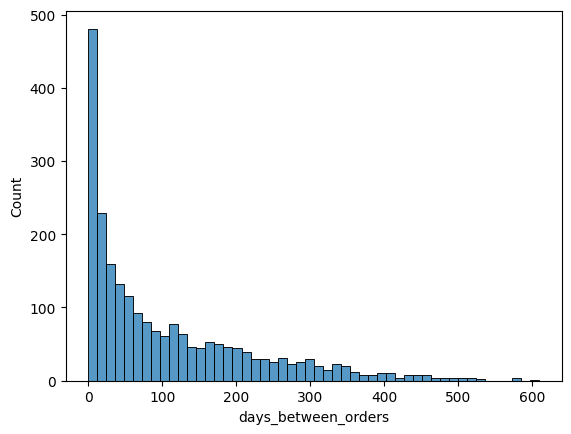

In [24]:
sns.histplot(dbo_df['days_between_orders'], bins=50)
plt.show()

Among customers who reordered, the median time to a
second order is ~62 days; 75% reorder within ~167 days, 90% within ~281 days.
Most repeat customers come back
quickly, but a shrinking share take much longer to return.

**Step 2 — Choosing the comparison window (W)**

```sql

WITH
    valid_orders AS (
        SELECT
            order_id, customer_id,
            NULLIF(TRIM(order_purchase_timestamp), '')::timestamp AS purchase_ts,
            NULLIF(TRIM(order_delivered_customer_date), '')::date AS delivered_date,
            NULLIF(TRIM(order_estimated_delivery_date), '')::date AS estimated_date
        FROM
            target.orders
        WHERE
            order_status = 'delivered'
            AND NULLIF(TRIM(order_estimated_delivery_date), '') IS NOT NULL
            AND NULLIF(TRIM(order_delivered_customer_date), '') IS NOT NULL
    ),

    first_valid_order AS (
        SELECT
            c.customer_unique_id,
            MIN(vo.purchase_ts) AS first_purchase
        FROM
            target.customers c
        JOIN
            valid_orders vo ON c.customer_id = vo.customer_id
        GROUP BY 1
    ),

    dataset_end AS (
        SELECT MAX(NULLIF(TRIM(order_purchase_timestamp), '')::timestamp) AS max_ts
        FROM target.orders
    )

SELECT
    COUNT(*) AS total_customers,
    SUM(CASE WHEN fvo.first_purchase <= de.max_ts - INTERVAL '60 days' THEN 1 ELSE 0 END) AS eligible_w60,
    SUM(CASE WHEN fvo.first_purchase <= de.max_ts - INTERVAL '90 days' THEN 1 ELSE 0 END) AS eligible_w90,
    SUM(CASE WHEN fvo.first_purchase <= de.max_ts - INTERVAL '180 days' THEN 1 ELSE 0 END) AS eligible_w180,
    SUM(CASE WHEN fvo.first_purchase <= de.max_ts - INTERVAL '281 days' THEN 1 ELSE 0 END) AS eligible_w281
FROM
    first_valid_order fvo, dataset_end de

| W | Eligible customers | % of total |
|---|---|---|
| 60 days | 91,948 | 98.5% |
| 90 days | 84,371 | 90.4% |
| 180 days | 66,668 | 71.4% |
| 281 days | 44,120 | 47.3% |

At W = 281 days (the 90th percentile of reorder time), eligible customers
drop to under half the dataset — a steep sample-size cost. We use **W = 180
days** instead: it captures more reorder behavior than a shorter window while
keeping ~71% of customers eligible, a better balance than chasing the 90th
percentile at the cost of nearly half the sample.

**Step 3 — Classify customers and apply the eligibility window**

For each customer, we identify their first *valid* (delivered) order and
classify it as delayed or on-time. Customers are kept in the analysis only if
this reference order occurred at least 180 days before the dataset's last
recorded purchase — ensuring every customer had an equal chance to reorder
within the window.

```sql
WITH valid_orders AS (
    SELECT
        order_id, customer_id,
        NULLIF(TRIM(order_purchase_timestamp), '')::timestamp AS purchase_ts,
        NULLIF(TRIM(order_delivered_customer_date), '')::date AS delivered_date,
        NULLIF(TRIM(order_estimated_delivery_date), '')::date AS estimated_date
    FROM target.orders
    WHERE order_status = 'delivered'
        AND NULLIF(TRIM(order_estimated_delivery_date), '') IS NOT NULL
        AND NULLIF(TRIM(order_delivered_customer_date), '') IS NOT NULL
),

first_orders AS (
    SELECT
        customer_unique_id,
        purchase_ts AS first_order,customer_id,
        CASE WHEN delivered_date > estimated_date THEN 'delay' ELSE 'on-time' END AS delivery
    FROM (
        SELECT
            c.customer_unique_id,
            vo.purchase_ts,
            vo.delivered_date,
            vo.estimated_date,c.customer_id,
            ROW_NUMBER() OVER (
                PARTITION BY c.customer_unique_id
                ORDER BY vo.purchase_ts, vo.order_id
            ) AS rnk
        FROM target.customers c
        JOIN valid_orders vo ON c.customer_id = vo.customer_id
    ) ranked
    WHERE rnk = 1
),

eligible_customers as (select customer_unique_id,customer_id, first_order,delivery from first_orders
 where first_order <= ( SELECT MAX(NULLIF(TRIM(order_purchase_timestamp), '')::timestamp)-interval '180 days'
        FROM target.orders))
        
        
select customer_unique_id, first_order, delivery from eligible_customers

**Step 4 — Did they reorder within the window?**


For each eligible customer, we check whether they placed any subsequent order
(any status) within 180 days of their reference order, then compare the
reorder rate between the delayed and on-time groups.

```sql
WITH valid_orders AS (
    SELECT
        order_id, customer_id,
        NULLIF(TRIM(order_purchase_timestamp), '')::timestamp AS purchase_ts,
        NULLIF(TRIM(order_delivered_customer_date), '')::date AS delivered_date,
        NULLIF(TRIM(order_estimated_delivery_date), '')::date AS estimated_date
    FROM target.orders
    WHERE order_status = 'delivered'
        AND NULLIF(TRIM(order_estimated_delivery_date), '') IS NOT NULL
        AND NULLIF(TRIM(order_delivered_customer_date), '') IS NOT NULL
),

first_orders AS (
    SELECT
        customer_unique_id,
        purchase_ts AS first_order,
        CASE WHEN delivered_date > estimated_date THEN 'delay' ELSE 'on-time' END AS delivery
    FROM (
        SELECT
            c.customer_unique_id,
            vo.purchase_ts,
            vo.delivered_date,
            vo.estimated_date,
            ROW_NUMBER() OVER (
                PARTITION BY c.customer_unique_id
                ORDER BY vo.purchase_ts, vo.order_id
            ) AS rnk
        FROM target.customers c
        JOIN valid_orders vo ON c.customer_id = vo.customer_id
    ) ranked
    WHERE rnk = 1
),

eligible_customers AS (
    SELECT customer_unique_id, first_order, delivery
    FROM first_orders
    WHERE first_order <= (
        SELECT MAX(NULLIF(TRIM(order_purchase_timestamp), '')::timestamp)
        FROM target.orders
    ) - INTERVAL '180 days'
),

all_orders_uid AS (
    SELECT
        c.customer_unique_id,
        NULLIF(TRIM(o.order_purchase_timestamp), '')::timestamp AS purchase_ts
    FROM target.orders o
    JOIN target.customers c ON o.customer_id = c.customer_id
    WHERE NULLIF(TRIM(o.order_purchase_timestamp), '') IS NOT NULL
),

reorder_flag AS (
    SELECT
        ec.customer_unique_id,
        ec.delivery,
        MAX(
            CASE WHEN ao.purchase_ts > ec.first_order
                  AND ao.purchase_ts <= ec.first_order + INTERVAL '180 days'
                 THEN 1 ELSE 0 END
        ) AS reordered
    FROM eligible_customers ec
    LEFT JOIN all_orders_uid ao ON ao.customer_unique_id = ec.customer_unique_id
    GROUP BY ec.customer_unique_id, ec.delivery
)

SELECT
    delivery,
    COUNT(*) AS total_eligible,
    SUM(reordered) AS reordered_count,
    ROUND(100.0 * SUM(reordered) / COUNT(*), 2) AS reorder_rate_pct
FROM reorder_flag
GROUP BY delivery

| Group | Eligible customers | Reordered | Reorder rate |
|---|---|---|---|
| Delay | 5,187 | 121 | 2.33% |
| On-time | 61,481 | 1,691 | 2.75% |

Customers whose first order arrived late reordered at a lower rate than
customers whose first order arrived on time — 2.33% vs. 2.75%, a gap of
~0.42 percentage points (roughly 15% lower in relative terms).

As a consistency check: delayed customers make up ~7.8% of eligible
customers here, close to the 6.77% overall late-delivery rate found in Q1 —
the two analyses agree on the rough scale of the delay problem.

In [25]:
from statsmodels.stats.proportion import proportions_ztest

# counts: [reordered_delayed, reordered_ontime], totals: [total_delayed, total_ontime]
reordered = [121, 1691]
totals = [5187, 61481]

z_stat, p_value = proportions_ztest(count=reordered, nobs=totals)

print(f"z-statistic: {z_stat:.3f}")
print(f"p-value: {p_value:.4f}")

z-statistic: -1.777
p-value: 0.0756


### Statistical significance check

To test whether the observed gap in reorder rates (2.33% delayed vs. 2.75%
on-time) reflects a real difference or could plausibly be due to chance, we
ran a two-proportion z-test.

**Result:** z = -1.777, p = 0.0756

At the conventional 0.05 threshold, this result is not statistically
significant — meaning we cannot confidently rule out chance as the
explanation for the gap. The p-value is close to the threshold, suggesting
a real effect is plausible but not confirmed at this sample size. We report
this finding as directionally suggestive rather than conclusive.

## **Q4: Which states have the worst delivery delay rates?:**

Applying the same late-delivery definition from Q1, grouped by customer state, to see whether delays cluster geographically or are spread evenly across Brazil.

```sql
-- State = customer_state (delivery destination), not seller_state

WITH valid_orders AS (
    SELECT
        order_id, customer_id,
        NULLIF(TRIM(order_purchase_timestamp), '')::timestamp AS purchase_ts,
        NULLIF(TRIM(order_delivered_customer_date), '')::date AS delivered_date,
        NULLIF(TRIM(order_estimated_delivery_date), '')::date AS estimated_date
    FROM target.orders
    WHERE order_status = 'delivered'
        AND NULLIF(TRIM(order_estimated_delivery_date), '') IS NOT NULL
        AND NULLIF(TRIM(order_delivered_customer_date), '') IS NOT NULL
),

state_wise_orders AS (
    SELECT
        c.customer_state,
        CASE WHEN vo.delivered_date > vo.estimated_date THEN 'delay' ELSE 'on-time' END AS delivery
    FROM target.customers c
    JOIN valid_orders vo ON c.customer_id = vo.customer_id
)

SELECT
    customer_state,
    COUNT(*) AS total_orders,
    ROUND(SUM(CASE WHEN delivery = 'on-time' THEN 1 ELSE 0 END)::numeric * 100 / COUNT(*), 2) AS on_time_rate,
    ROUND(SUM(CASE WHEN delivery = 'delay' THEN 1 ELSE 0 END)::numeric * 100 / COUNT(*), 2) AS delay_rate
FROM state_wise_orders
GROUP BY 1
ORDER BY 4 DESC

In [26]:
state_wise_delay_rate = pd.read_csv(sql_base_url + "q4_state_wise_delay_rate.csv")
state_wise_delay_rate

,customer_state,total_orders,on_time_rate,delay_rate
0,AL,397,78.59,21.41
1,MA,717,82.57,17.43
2,SE,335,84.78,15.22
3,PI,476,86.13,13.87
4,CE,1279,86.24,13.76
5,RR,41,87.80,12.20
6,BA,3256,87.84,12.16
7,RJ,12350,87.89,12.11
8,PA,946,88.79,11.21
9,ES,1995,89.27,10.73


### Reliability flag and ranked view

States with fewer than 100 delivered orders are flagged as unreliable due to small-sample volatility, but kept in the dataset for transparency.

In [27]:
state_wise_delay_rate['reliable_state'] = state_wise_delay_rate['total_orders']>=100
state_wise_delay_rate.head()

,customer_state,total_orders,on_time_rate,delay_rate,reliable_state
0,AL,397,78.59,21.41,True
1,MA,717,82.57,17.43,True
2,SE,335,84.78,15.22,True
3,PI,476,86.13,13.87,True
4,CE,1279,86.24,13.76,True


In [28]:
# Sanity checks
print(f"Total states: {len(state_wise_delay_rate)}")
print(f"Reliable states: {state_wise_delay_rate['reliable_state'].sum()}")
print(f"Total orders across all states: {state_wise_delay_rate['total_orders'].sum()}")

Total states: 27
Reliable states: 24
Total orders across all states: 96470


In [29]:
# Ranked view — reliable states only, worst delay rate first
ranked = state_wise_delay_rate[state_wise_delay_rate['reliable_state']].sort_values('delay_rate', ascending=False)
print("\nTop 5 worst delay rates:")
print(ranked[['customer_state', 'total_orders', 'delay_rate']].head())



Top 5 worst delay rates:
  customer_state  total_orders  delay_rate
0             AL           397       21.41
1             MA           717       17.43
2             SE           335       15.22
3             PI           476       13.87
4             CE          1279       13.76


In [30]:
# Best delay rates
print("\nTop 5 best delay rates:")
print(ranked[['customer_state', 'total_orders', 'delay_rate']].tail())


Top 5 best delay rates:
   customer_state  total_orders  delay_rate
20             MG         11354        4.57
21             SP         40494        4.49
22             PR          4923        4.04
25             RO           243        2.88
26             AM           145        2.76


### Chart: delay rate by state

Flagged (low-sample) states are shown in gray and excluded from the ranking narrative, but included on the chart for transparency.

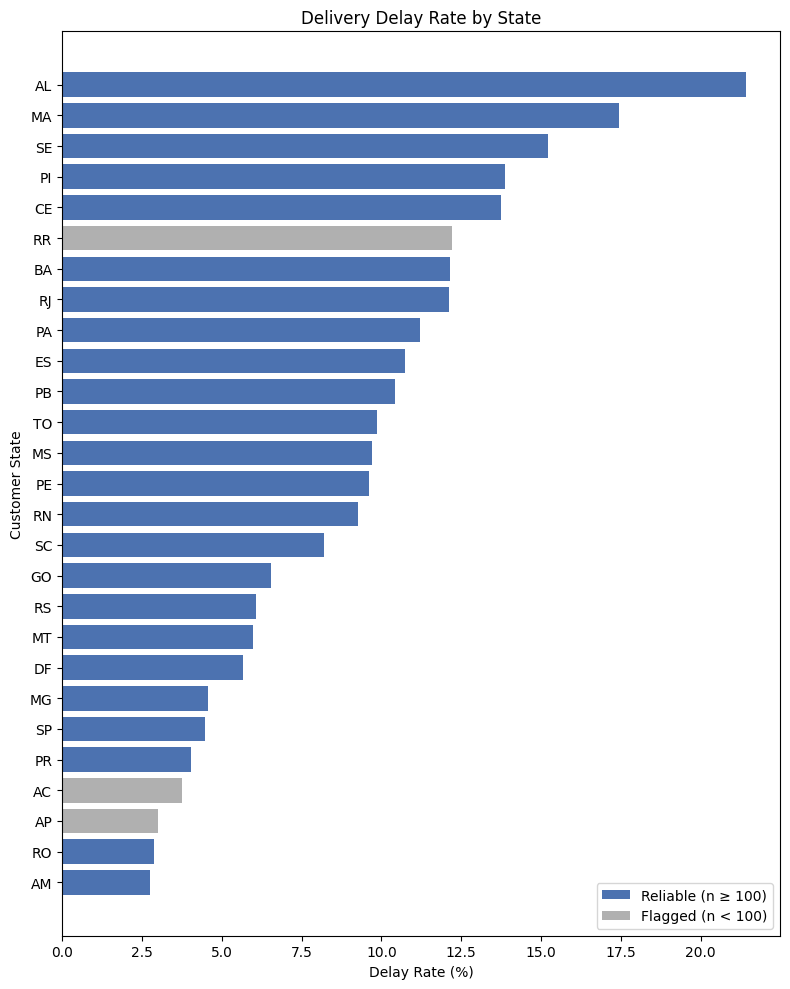

In [31]:
import matplotlib.pyplot as plt

plot_df = state_wise_delay_rate.sort_values('delay_rate', ascending=True)
colors = plot_df['reliable_state'].map({True: '#4C72B0', False: '#B0B0B0'})

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(plot_df['customer_state'], plot_df['delay_rate'], color=colors)

ax.set_xlabel('Delay Rate (%)')
ax.set_ylabel('Customer State')
ax.set_title('Delivery Delay Rate by State')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='Reliable (n ≥ 100)'),
    Patch(facecolor='#B0B0B0', label='Flagged (n < 100)')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

Delay rates ranged from 2.76% to 21.41% among states with a reliable sample size (≥100 orders). The worst — Alagoas, Maranhão, Sergipe, Piauí, and Ceará (all 13–21%) — are concentrated in the North/Northeast, well above the 6.77% national baseline. São Paulo and Minas Gerais, the two highest-volume states, stay close to it (~4.5%). Three low-volume states (n=41–80) were excluded from ranking due to sample noise.

Delays cluster geographically rather than spreading evenly.

## Q5: Revenue at risk from delivery delays

`Revenue at risk = delayed customers × drop in repeat-purchase rate × avg order value`

**Average Order Value**

```sql
--- Order value basis: price + freight_value from order_items (goods value); checked against SUM(payment_value)
---from payments and the two bases converge within ~1%, so the choice doesn't materially affect the result.

WITH
	valid_orders AS (
		SELECT
			order_id,
			customer_id,
			NULLIF(TRIM(order_purchase_timestamp), '')::timestamp AS purchase_ts,
			NULLIF(TRIM(order_delivered_customer_date), '')::date AS delivered_date,
			NULLIF(TRIM(order_estimated_delivery_date), '')::date AS estimated_date
		FROM
			target.orders
		WHERE
			order_status = 'delivered'
			AND NULLIF(TRIM(order_estimated_delivery_date), '') IS NOT NULL
			AND NULLIF(TRIM(order_delivered_customer_date), '') IS NOT NULL
	),
	delay_orders AS (
		SELECT
			CASE
				WHEN vo.delivered_date > vo.estimated_date THEN 'delay'
				ELSE 'on-time'
			END AS delivery,
			vo.order_id,
			oi.price,
			oi.freight_value
		FROM
			target.order_items oi
			JOIN valid_orders vo ON oi.order_id = vo.order_id
	)
SELECT
	round(sum(price + freight_value)::numeric / count(DISTINCT order_id), 2) AS avg_order_value
FROM
	delay_orders
WHERE
	delivery = 'delay'

In [32]:
aov_df = pd.read_csv(sql_base_url + "q5_avg_order_value.csv")
aov = aov_df['avg_order_value'].iloc[0]
print(f"Average order value (delayed orders): {aov:.2f}")

Average order value (delayed orders): 176.14


**Eligible delayed customers (primary population)**

```sql
--- eligible = first_order <= (max purchase_ts across all orders - 180 days)

WITH valid_orders AS (
    SELECT
        order_id, customer_id,
        NULLIF(TRIM(order_purchase_timestamp), '')::timestamp AS purchase_ts,
        NULLIF(TRIM(order_delivered_customer_date), '')::date AS delivered_date,
        NULLIF(TRIM(order_estimated_delivery_date), '')::date AS estimated_date
    FROM target.orders
    WHERE order_status = 'delivered'
        AND NULLIF(TRIM(order_estimated_delivery_date), '') IS NOT NULL
        AND NULLIF(TRIM(order_delivered_customer_date), '') IS NOT NULL
),

first_orders AS (
    SELECT
        customer_unique_id, customer_id, purchase_ts AS first_order,
        CASE WHEN delivered_date > estimated_date THEN 'delay' ELSE 'on-time' END AS delivery
    FROM (
        SELECT
            c.customer_unique_id, c.customer_id,
            vo.purchase_ts, vo.delivered_date, vo.estimated_date,
            ROW_NUMBER() OVER (
                PARTITION BY c.customer_unique_id
                ORDER BY vo.purchase_ts, vo.order_id
            ) AS rnk
        FROM target.customers c
        JOIN valid_orders vo ON c.customer_id = vo.customer_id
    ) ranked
    WHERE rnk = 1
),

eligible_customers AS (
    SELECT customer_unique_id, customer_id, first_order, delivery
    FROM first_orders
    WHERE first_order <= (
        SELECT MAX(NULLIF(TRIM(order_purchase_timestamp), '')::timestamp) - INTERVAL '180 days'
        FROM target.orders
    )
)

SELECT COUNT(*) AS eligible_delayed_customers
FROM eligible_customers
WHERE delivery = 'delay'

In [33]:
eligible_df = pd.read_csv(sql_base_url + "q5_num_eligible_delay_cust.csv")
num_delayed_customers = eligible_df['eligible_delayed_customers'].iloc[0]
print(f"Eligible delayed customers (W=180 population): {num_delayed_customers}")

Eligible delayed customers (W=180 population): 5187


**All delayed customers (sensitivity population)**

```sql
WITH
	valid_orders AS (
		SELECT
			order_id,
			customer_id,
			NULLIF(TRIM(order_purchase_timestamp), '')::timestamp AS purchase_ts,
			NULLIF(TRIM(order_delivered_customer_date), '')::date AS delivered_date,
			NULLIF(TRIM(order_estimated_delivery_date), '')::date AS estimated_date
		FROM
			target.orders
		WHERE
			order_status = 'delivered'
			AND NULLIF(TRIM(order_estimated_delivery_date), '') IS NOT NULL
			AND NULLIF(TRIM(order_delivered_customer_date), '') IS NOT NULL
	),
	first_orders AS (
		SELECT
			customer_unique_id,
			purchase_ts AS first_order,
			customer_id,
			CASE
				WHEN delivered_date > estimated_date THEN 'delay'
				ELSE 'on-time'
			END AS delivery
		FROM
			(
				SELECT
					c.customer_unique_id,
					vo.purchase_ts,
					vo.delivered_date,
					vo.estimated_date,
					c.customer_id,
					ROW_NUMBER() OVER (
						PARTITION BY
							c.customer_unique_id
						ORDER BY
							vo.purchase_ts,
							vo.order_id
					) AS rnk
				FROM
					target.customers c
					JOIN valid_orders vo ON c.customer_id = vo.customer_id
			) ranked
		WHERE
			rnk = 1	)
SELECT
	count(*) AS num_all_delayed_customers
FROM
	first_orders
WHERE
	delivery = 'delay'

In [34]:
all_delay_df = pd.read_csv(sql_base_url + "q5_num_all_delay_cust.csv")
num_delayed_customers_all = all_delay_df['num_all_delayed_customers'].iloc[0]
print(f"All delayed customers (no W=180 filter): {num_delayed_customers_all}")

All delayed customers (no W=180 filter): 6355


In [35]:
rate_gap = 0.0042  # Q3 — absolute gap: 2.75% (on-time) - 2.33% (delayed)

# Population (a) — primary: eligible delayed customers (W=180 retained population)
revenue_at_risk_a = num_delayed_customers * rate_gap * aov

# Population (b) — sensitivity: all delayed customers, no W=180 eligibility filter
revenue_at_risk_b = num_delayed_customers_all * rate_gap * aov

print(f"(a) Primary estimate:        {revenue_at_risk_a:,.2f}")
print(f"(b) Sensitivity estimate:    {revenue_at_risk_b:,.2f}")

(a) Primary estimate:        3,837.28
(b) Sensitivity estimate:    4,701.35


### Interpretation

Revenue at risk works out to **3,837** under the primary estimate — using only the ~71% of delayed customers Q3 could actually observe for a full 180-day window — and **4,701** under a sensitivity estimate that assumes the same reorder-rate gap extends to the full delayed population. The ~22% difference between the two is fully explained by the difference in customer counts (5,187 vs. 6,355); rate and order value are held constant across both.

The primary estimate is the one we'd stand behind: it doesn't extrapolate beyond the population the rate was actually measured on. The sensitivity estimate is included as a labeled "what if this generalizes" figure, not a claim.

Both numbers are modest — roughly 0.02–0.03% of total order value (~15.84M) — and that's expected rather than a weak result. Three conservative choices compound to produce it: the underlying rate gap from Q3 didn't clear statistical significance (p = 0.076), we used the absolute rather than relative gap, and we didn't extrapolate past the directly observed population. Read together with Q3, this figure is the caveats from that analysis showing up numerically rather than just in a footnote.

**Bottom line:** delivery delays are associated with a modest, not dramatic, measurable revenue impact through reduced repeat purchases — real enough to be worth acting on, but not large enough to justify urgent, costly intervention on its own.

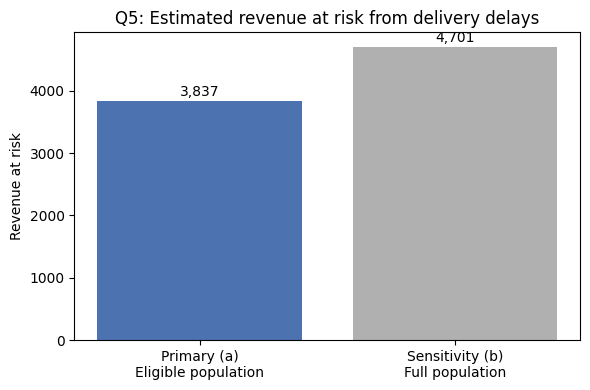

In [36]:
import matplotlib.pyplot as plt

labels = ['Primary (a)\nEligible population', 'Sensitivity (b)\nFull population']
values = [revenue_at_risk_a, revenue_at_risk_b]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, values, color=['#4C72B0', '#B0B0B0'])
ax.set_ylabel('Revenue at risk')
ax.set_title('Q5: Estimated revenue at risk from delivery delays')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 30, f"{val:,.0f}",
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()